# Week 4 Seminar

**Chapter 5: Resampling Methods: Bootstrap, CV (ISLP textbook)**

**Course:** ML1, 2025/2026, HSE

**Author:** Boris Tseytlin, Teaching Team

**Revised by:** Aleksandr Khizhik

---

This week we will be covering two resampling techniques you can use to assess your machine learning models:
* Cross-Validation
* Bootstrap

In [4]:
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Increase viewable area of Pandas tables, numpy arrays, plots
pd.set_option('display.max_rows', 15, 'display.max_columns', 500, 'display.max_colwidth', 1, 'display.precision', 2)
np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)

# Visualizations
sns.set_theme()
plt.rcParams['figure.figsize'] = [16, 6]

# Random
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Loading data

We will load the Titanic dataset, perform the same preprocessing as we did on week 3, and train a simple model.

In [5]:
csv_url = 'https://raw.githubusercontent.com/omelnikov/data/main/titanic/titanic.csv'
df = pd.read_csv(csv_url)
df.columns=['psgr','srv','pcls','name','sex','age','sibsp','parch','tkt','fare','cabin','emb']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   psgr    891 non-null    int64  
 1   srv     891 non-null    int64  
 2   pcls    891 non-null    int64  
 3   name    891 non-null    object 
 4   sex     891 non-null    object 
 5   age     714 non-null    float64
 6   sibsp   891 non-null    int64  
 7   parch   891 non-null    int64  
 8   tkt     891 non-null    object 
 9   fare    891 non-null    float64
 10  cabin   204 non-null    object 
 11  emb     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Leakage

Data leakage happens when we compute data-dependent preprocessing (e.g., median imputation, 95th-percentile capping) **before** splitting into train/validation/test.
That lets the model "peek" at validation/test statistics and yields overly optimistic scores.

**Principle:** put *all* data-dependent steps inside an sklearn `Pipeline`, so each fold/split fits its own preprocessing **using only the training portion**.

We’ll:

1. Build features inside a transformer (drop text/id columns, encode `emb`, ensure `sex` is numeric).
2. Fit a winsorizer (caps `fare`/`sibsp` at fold-specific 95th percentiles).
3. Impute missing values (median) *within the fold*.
4. Scale features (so KNN isn’t dominated by large-scale features).

In [7]:
# Target
TARGET = "srv"

# Raw features
X_raw = df.drop(columns=[TARGET]).copy()
y = df[TARGET].to_numpy()

# Keep an index handy for plots elsewhere
index = X_raw.index

## Custom transformers for safe, fold-local preprocessing

* `FeatureBuilder` encodes `emb`, ensures `sex` is numeric, and drops text/id columns.
* `Winsorizer` learns the 95th percentile **on the training split only** and caps values during `transform`.

In [8]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    """
    - Create emb_is_S / emb_is_C from 'emb'
    - Ensure 'sex' is 0/1
    - Drop text/id columns: 'psgr', 'cabin', 'tkt', 'name'
    """
    def __init__(self, drop_cols=('psgr', 'cabin','tkt','name'), emb_col='emb'):
        self.drop_cols = drop_cols
        self.emb_col = emb_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Encode 'sex'
        if 'sex' in X.columns and X['sex'].dtype.kind not in 'biu':
            X['sex'] = (X['sex'] == 'male').astype(int)

        # Convert categorical features `emb` with three possible values to two binary features
        if self.emb_col in X.columns:
            X['emb_is_S'] = (X[self.emb_col] == 'S').astype(int)
            X['emb_is_C'] = (X[self.emb_col] == 'C').astype(int)
            X = X.drop(columns=[self.emb_col])

        # Drop non-predictive text/id columns
        to_drop = [c for c in list(self.drop_cols) if c in X.columns]
        if to_drop:
            X = X.drop(columns=to_drop)
        return X


class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Cap selected columns at an upper quantile learned on the TRAINING data only.
    This avoids leakage that happens when using full-data quantiles.
    """
    def __init__(self, columns=('fare','sibsp'), upper_q=0.95):
        self.columns = columns
        self.upper_q = upper_q
        self.upper_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        cols = [c for c in list(self.columns) if c in X.columns]
        # Learn quantiles on training fold only
        self.upper_ = {
            col: np.nanquantile(X[col], self.upper_q) for col in self.columns if col in X.columns
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col, q in self.upper_.items():
            if col in X.columns:
                X[col] = np.minimum(X[col], q)
        return X

This pipeline is what you should use everywhere (single split, CV, grid-search).

In [9]:
preprocess = Pipeline([
    ("features",  FeatureBuilder()),
    ("winsor",    Winsorizer(columns=('fare','sibsp'), upper_q=0.95)),
    ("impute",    SimpleImputer(strategy="median")),
    ("scale",     StandardScaler()),
])

pipe = Pipeline([
    ("prep", preprocess),
    ("clf",  KNeighborsClassifier(n_neighbors=3, n_jobs=-1)),
])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, shuffle=True
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict_proba(X_test)[:, 1]
score = roc_auc_score(y_test, y_pred)
print("ROC AUC:", score)

ROC AUC: 0.8398175245309003


We obtained some ROC AUC score for our classifier. However, if we rerun this cell a few times, we will get different results.
Let's confirm that:

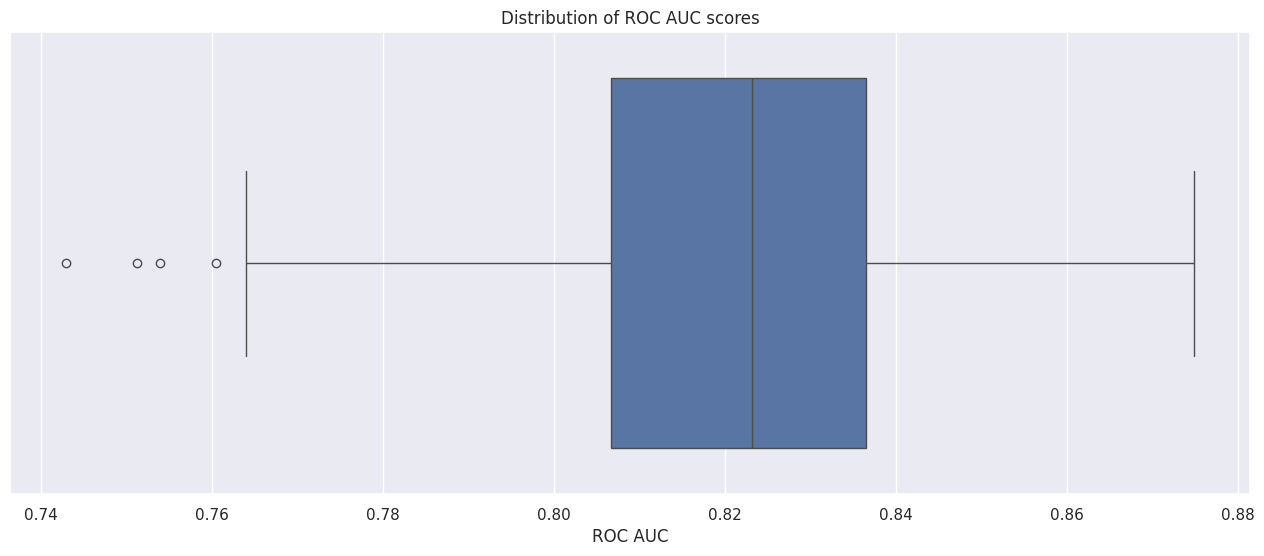

In [11]:
scores = []
for i in range(250):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_raw, y, test_size=0.3, shuffle=True, random_state=SEED + i
    )
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict_proba(X_te)[:, 1]
    scores.append(roc_auc_score(y_te, y_pred))

plt.figure()
sns.boxplot(x=scores)
plt.title('Distribution of ROC AUC scores')
plt.xlabel('ROC AUC')
plt.show()

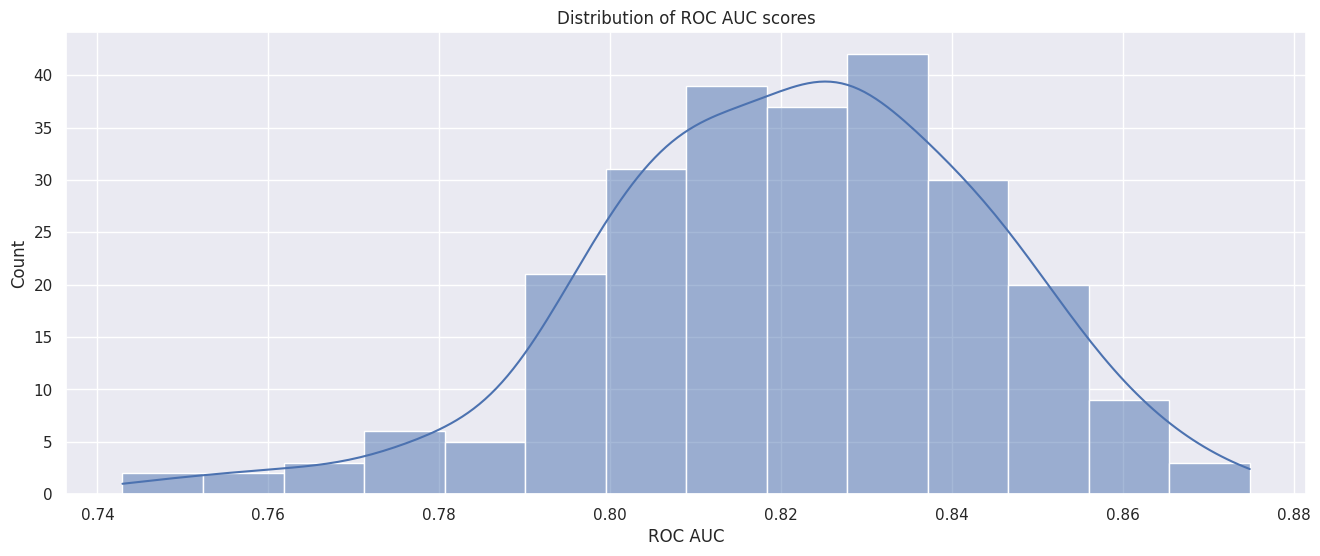

In [12]:
plt.figure()
sns.histplot(scores, kde=True)
plt.title('Distribution of ROC AUC scores')
plt.xlabel('ROC AUC')
plt.show()

The scores can vary up to 0.1 in absolute value between different runs!

**Takeaway:**
The performance of a model is heavily dependent on the train-test split.

Therefore we can't use train-test splits to get reliable estimates of model performance. That also means that we can't use them to reliably find the best hyperparameters (like the $k$ parameter for KNN).

We want to know how good our model is **overall**.  We would like a method that does not depend on one exact data split. It should be reliable and reasonably fast. Such a method exists and it's called Cross-Validation.



# Cross-Validation

The idea behind Cross-Validation:
1. Perform multiple splits.
2. For each split, fit a model to the training set, predict and compute a score (e.g. accuracy) on the validation set.
3. Average the results, obtain confidence intervals.

There are many ways to perform the first step. In general, you want each observation to appear in at least one validation set.

For maximum reliability, you could make as many splits as you have observations ($N$). But this is very slow, because you have to fit $N$ models. So instead you might want to make a few non-overlapping splits with $k < N$ observations in each, so that you can fit fewer models and achieve similar results. We will try these and other methods below.

Cross-validation can be used for:
* Obtaining a reliable estimate of test set error.
* Comparing models in terms of performance.
* Finding the best values for hyperparameters.

Source of plotting helpers: [sklearn docs](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html)

### Some plotting helpers

In [13]:
def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""

    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=group)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes and groups at the end
    ax.scatter(range(len(X)), [ii + 1.5] * len(X),
               c=y, marker='_', lw=lw, cmap=cmap_data)

    ax.scatter(range(len(X)), [ii + 2.5] * len(X),
               c=group, marker='_', lw=lw, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ['class', 'group']
    ax.set(yticks=np.arange(n_splits+2) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="CV iteration",
           ylim=[n_splits+2.2, -.2], xlim=[0, 100])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
n_splits = 4

In [14]:
def draw_bars(bars, y=0.5, vmin=-.2, vmax=1.2, label=None):
    ax = plt.gca()
    ax.scatter(range(len(bars)),  [y] * len(bars), c=bars, marker='_',
               lw=50, label=label, cmap=cmap_cv, vmin=vmin, vmax=vmax)

## Train-test split visualized

First of all, let's take a look at our train-test split.

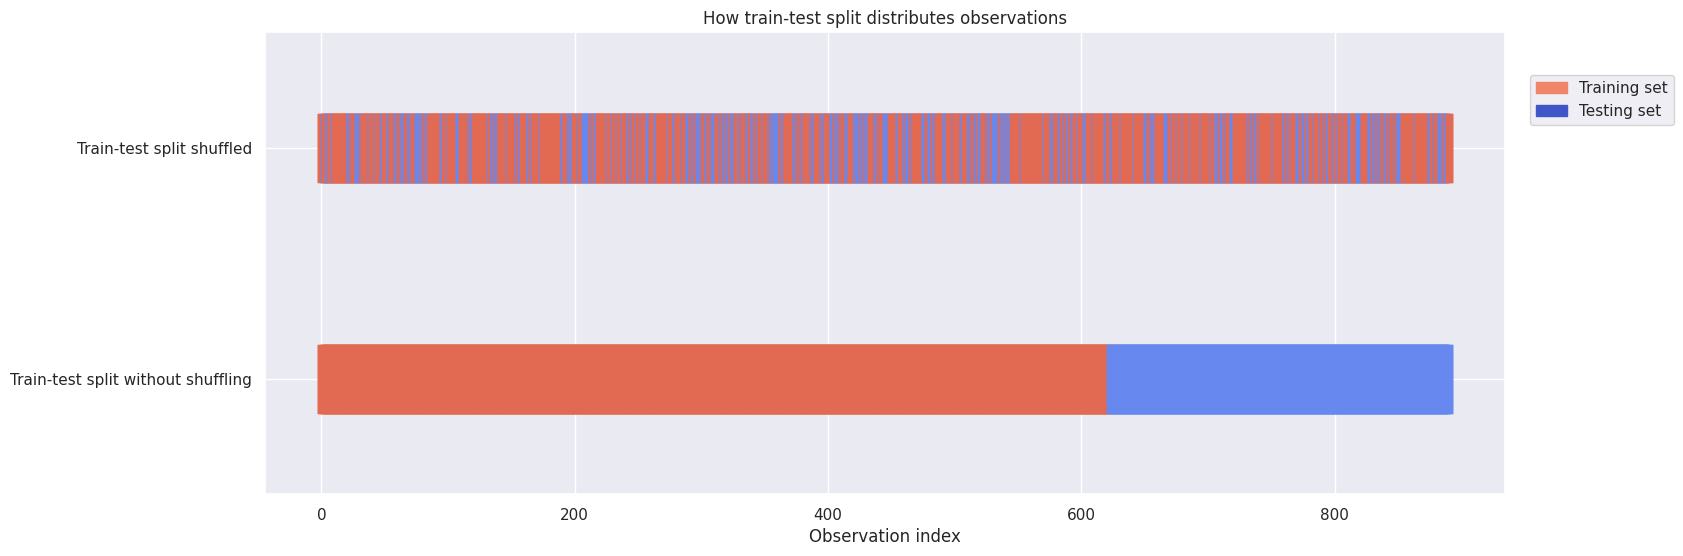

In [15]:
train_idx, test_idx = train_test_split(index, test_size=0.3, shuffle=False, random_state=SEED)
idx_labels = np.array([(idx in set(train_idx)) for idx in index])

train_idx_shuf, test_idx_shuf = train_test_split(index, test_size=0.3, shuffle=True, random_state=SEED)
idx_labels_shuffled = np.array([(idx in set(train_idx_shuf)) for idx in index])

plt.figure()
draw_bars(idx_labels, y=0.5)
draw_bars(idx_labels_shuffled, y=1.5)
plt.xlabel('Observation index')
plt.yticks([0.5, 1.5], ['Train-test split without shuffling', 'Train-test split shuffled'])
plt.legend([Patch(color=cmap_cv(.8)), Patch(color=cmap_cv(.02))],
           ['Training set', 'Testing set'], loc=(1.02, .8))
plt.ylim([0, 2])
plt.title('How train-test split distributes observations')
plt.show()

## K-Fold Cross-Validation

Idea: split dataset into $K$ **non-overlapping** groups. Each of the $K$ groups is used as a validation set once, while the other $K-1$ groups are used as the training set.

No shuffling is done by default, but usually it's good to do it as well.

In [16]:
def plot_cv_splits(cv, index, title, y_plot=None, y_split=None, groups=None):
    """
    Visualize which indices go to train/test for each split.
    - index: sequence of observation ids
    - y_plot: optional array just for the bottom "Class" row
    - y_split: labels actually passed to cv.split (must match the real order!)
    """
    plt.figure()
    y_ticks_pos, y_ticks = [], []
    for i, (train_idx, test_idx) in enumerate(cv.split(index, y=y_split, groups=groups)):
        idx_labels = np.array([(idx in set(train_idx)) for idx in index])
        draw_bars(idx_labels, y=0.5 + i)
        y_ticks_pos.append(0.5 + i)
        y_ticks.append(f'Fold {i}')

    if y_plot is not None:
        i += 1
        draw_bars(y_plot, y=0.5 + i, vmin=0.5, vmax=0.8)
        y_ticks_pos.append(0.5 + i)
        y_ticks.append('Class')

    plt.xlabel('Observation index')
    plt.yticks(y_ticks_pos, y_ticks)
    plt.legend([Patch(color=cmap_cv(.8)), Patch(color=cmap_cv(.02))],
               ['Training set', 'Testing set'], loc=(1.02, .8))
    plt.ylim([0, i + 1])
    plt.title(title)
    plt.show()

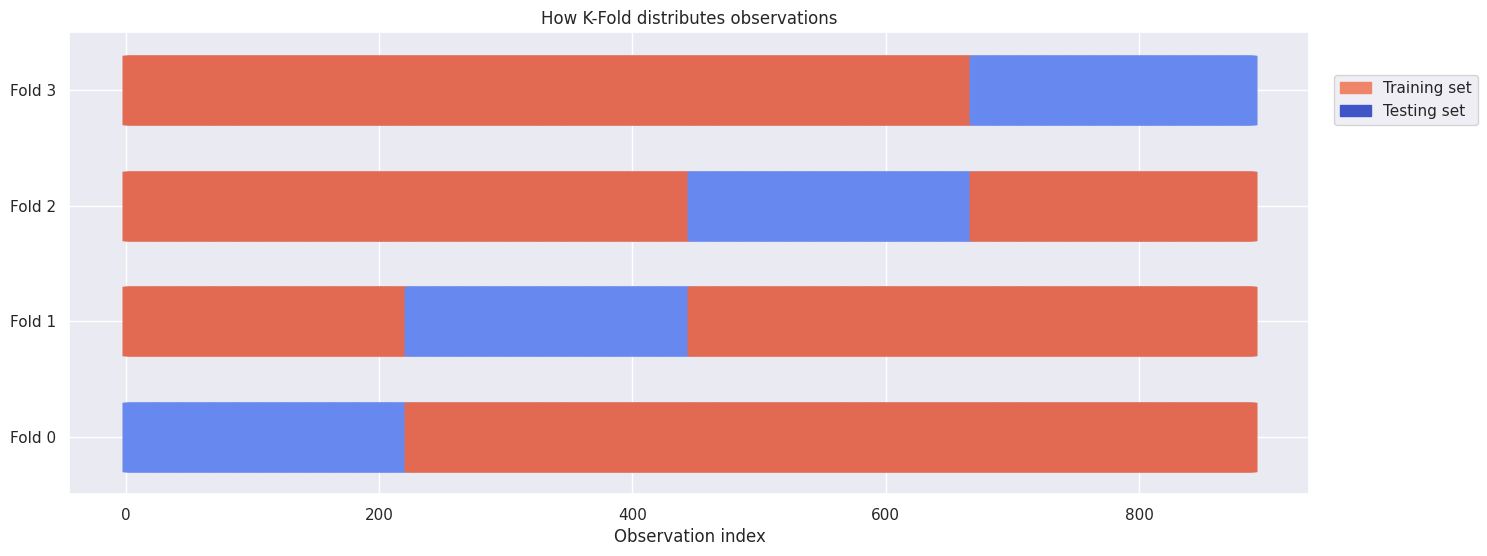

In [17]:
cv = KFold(n_splits, shuffle=False)
plot_cv_splits(cv, index, 'How K-Fold distributes observations')

### **Exercise:** implement your own K-Fold cross-validation

_Hint_: `np.random.shuffle(x)`

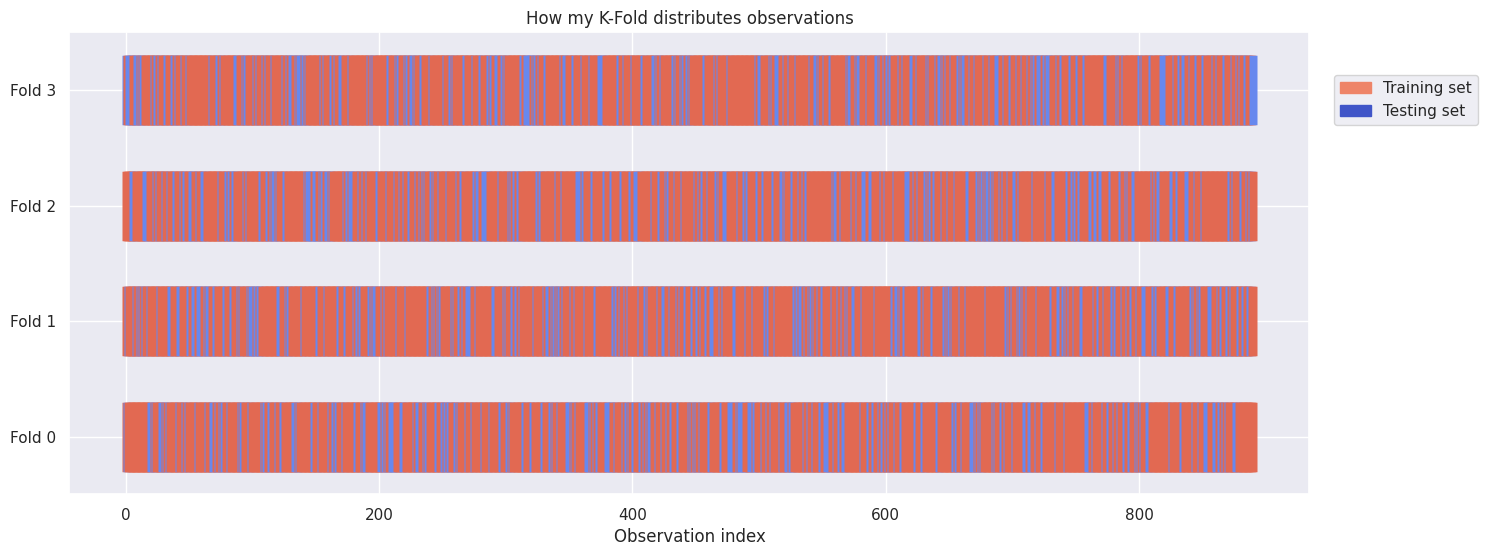

In [18]:
class MyKFold:
    def __init__(self, n_splits, shuffle=False):
        self.n_splits = n_splits
        self.shuffle = shuffle

    def split(self, x, *args, **kwargs):
        if self.shuffle:
          x = np.array(x)
          np.random.shuffle(x)

        length = len(x)
        cnt_in_split = length // self.n_splits
        for i in range(self.n_splits):
            start_index = i*cnt_in_split
            end_index = (i+1)*cnt_in_split
            if (i+2)*cnt_in_split > length:
                end_index = length
            val = x[start_index:end_index]
            train_start = x[:start_index]
            train_end = x[end_index:]
            train = np.concatenate([train_start, train_end])

            yield train, val

my_cv = MyKFold(n_splits, shuffle=True)
plot_cv_splits(my_cv, index, 'How my K-Fold distributes observations')

## Stratified K-Fold

K-Fold is great, but let's take a look at how it handles the classes of Titanic. I sort the target so that the plot is more illustrative.

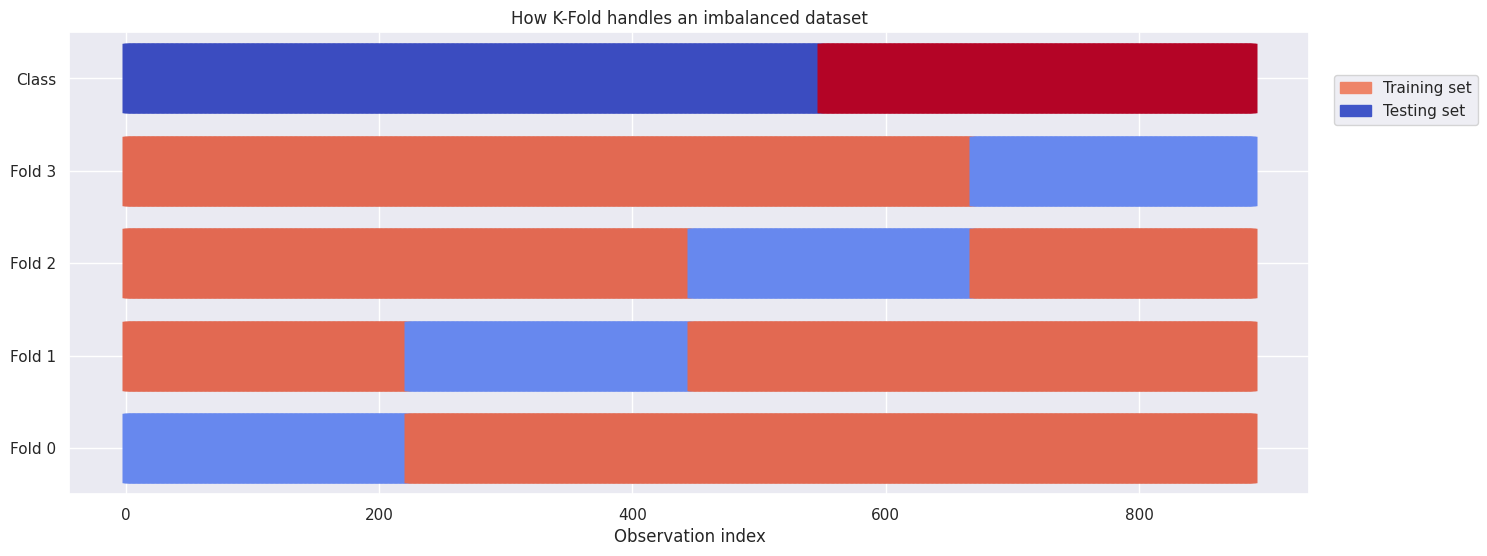

In [19]:
plot_cv_splits(cv, index, 'How K-Fold handles an imbalanced dataset', y_plot=np.sort(y))

This is not good: folds are going to have a different distribution of classes in them. We want to preserve the class distribution, so that our models can learn something actually useful.

**Stratified K-fold** makes sure that the original class distribution is preserved in each fold.

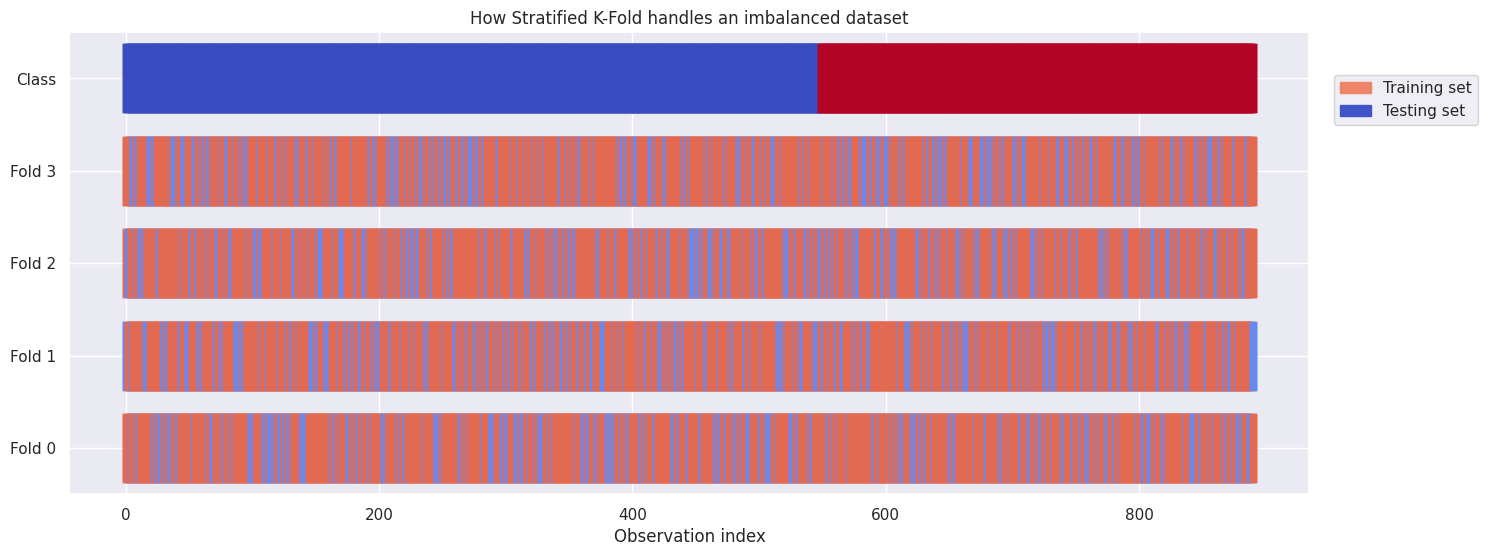

In [20]:
cv = StratifiedKFold(n_splits=n_splits, shuffle=True)

y_split = np.asarray(y)  # true labels, original order
y_plot = np.sort(y_split)  # purely for the visual "Class" band

plot_cv_splits(
    cv=cv,
    index=index,
    title='How Stratified K-Fold handles an imbalanced dataset',
    y_plot=y_plot,
    y_split=y_split
)

## Other notable CV methods available in sklearn

* [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html#sklearn.model_selection.GroupKFold) - same as K-Fold, except you can define groups of observations. Observations of some group will always appear in either training or validation set, but never in different sets.

* [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit) - the training sets are always in the past and the validation sets are always in the future, so that you are never training on the future to predict the past.

More [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation).

## Optimizing hyperparameters with CV

Remember how we were looking for the best $k$ value in the previous seminars? Previously we were simply trying some $k$ values on the same train-test split and seeing what worked best. It wasn't very reliable: perhaps the selected $k$ is only good for this exact split.


Now that we know about CV, let's do the following:
* Choose some $k$ value.
* For this value, run cross-validation and compute the mean ROC AUC.
* Pick the best $k$ value based on the best obtained ROC AUC.

In [21]:
# Fresh split for model selection
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, shuffle=True, random_state=SEED
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

params = {
    'clf__n_neighbors': range(1, 11),
    'clf__weights': ['uniform', 'distance'],
}

search = GridSearchCV(
    estimator=pipe, param_grid=params, cv=cv,
    n_jobs=-1, verbose=10, scoring='roc_auc'
)

In [22]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        Pipeline(steps=[('features',
                                                         FeatureBuilder()),
                                                        ('winsor',
                                                         Winsorizer()),
                                                        ('impute',
                                                         SimpleImputer(strategy='median')),
                                                        ('scale',
                                                         StandardScaler())])),
                                       ('clf',
                                        KNeighborsClassifier(n_jobs=-1,
                                                             n_neighbors=3))]),
             n_jobs=-1,
             param_grid={'clf__n_neighbors': range(1, 11),
                         'clf__weights': ['uniform', 'distance']},
             scoring='roc_auc', verbose=10)

In [23]:
print("Best estimator:", search.best_estimator_)
print("Mean CV ROC AUC:", search.best_score_)

Best estimator: Pipeline(steps=[('prep',
                 Pipeline(steps=[('features', FeatureBuilder()),
                                 ('winsor', Winsorizer()),
                                 ('impute', SimpleImputer(strategy='median')),
                                 ('scale', StandardScaler())])),
                ('clf', KNeighborsClassifier(n_jobs=-1))])
Mean CV ROC AUC: 0.8406921686766884


In [24]:
results_df = pd.DataFrame(search.cv_results_).sort_values(by='rank_test_score')
results_df.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__n_neighbors,param_clf__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.02,5.60e-03,0.03,7.25e-04,5,uniform,"{'clf__n_neighbors': 5, 'clf__weights': 'uniform'}",0.88,0.87,0.86,0.78,0.81,0.84,0.04,1
10,0.02,2.99e-03,0.02,1.22e-03,6,uniform,"{'clf__n_neighbors': 6, 'clf__weights': 'uniform'}",0.88,0.87,0.86,0.77,0.82,0.84,0.04,2
12,0.02,4.76e-03,0.03,2.61e-03,7,uniform,"{'clf__n_neighbors': 7, 'clf__weights': 'uniform'}",0.88,0.87,0.85,0.77,0.82,0.84,0.04,3
18,0.02,1.93e-03,0.03,2.03e-03,10,uniform,"{'clf__n_neighbors': 10, 'clf__weights': 'uniform'}",0.88,0.85,0.84,0.79,0.81,0.83,0.03,4
16,0.02,3.35e-03,0.03,1.99e-03,9,uniform,"{'clf__n_neighbors': 9, 'clf__weights': 'uniform'}",0.88,0.85,0.83,0.78,0.82,0.83,0.03,5
14,0.02,5.20e-03,0.02,6.51e-04,8,uniform,"{'clf__n_neighbors': 8, 'clf__weights': 'uniform'}",0.88,0.85,0.84,0.76,0.82,0.83,0.04,6
6,0.01,1.34e-03,0.03,3.76e-03,4,uniform,"{'clf__n_neighbors': 4, 'clf__weights': 'uniform'}",0.87,0.85,0.84,0.77,0.78,0.82,0.04,7
9,0.02,3.15e-03,0.03,2.30e-03,5,distance,"{'clf__n_neighbors': 5, 'clf__weights': 'distance'}",0.87,0.85,0.83,0.77,0.78,0.82,0.04,8
11,0.02,2.79e-03,0.04,1.64e-02,6,distance,"{'clf__n_neighbors': 6, 'clf__weights': 'distance'}",0.87,0.86,0.82,0.76,0.78,0.82,0.04,9
13,0.01,3.06e-03,0.03,4.45e-04,7,distance,"{'clf__n_neighbors': 7, 'clf__weights': 'distance'}",0.88,0.85,0.82,0.75,0.78,0.82,0.05,10


In [25]:
best_score = results_df.iloc[0]['mean_test_score']
best_k = results_df.iloc[0]['param_clf__n_neighbors']
print(f'The best ROC AUC {best_score:0.3f} is obtained for k={best_k}')

The best ROC AUC 0.841 is obtained for k=5


This result is much better than what we obtained in the previous seminar. However, it's not the test score yet. It's only the CV estimate of the test score. Depending on our CV pipeline, it could either be a good estimate for the real test score or a poor one.

Let's use the best obtained model to predict on the test set and check.

In [26]:
# Evaluate on held-out test set
y_pred = search.predict_proba(X_test)[:, 1]
score = roc_auc_score(y_test, y_pred)
print(f'Test set ROC AUC {score:0.3f}')

Test set ROC AUC 0.872


# Bootstrap

## The idea as plug-in for distributions
Let $X_1,\dots,X_n \stackrel{\text{i.i.d.}}{\sim} F$ and let your statistic be $\hat\theta = s(X_1,\dots,X_n)$.
You want features of the **sampling distribution** of $\hat\theta$ under the (unknown) $F$
— e.g., its variance, bias, or quantiles for confidence intervals.

The **bootstrap** replaces $F$ by the empirical distribution
$$
  \hat F_n(x) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}\{X_i \le x\},
$$
and studies $\hat\theta$ **conditional on the observed data** by generating
i.i.d. resamples $X_1^*,\dots,X_n^* \sim \hat F_n$ (with replacement). Define
$$
  \hat\theta^{*} = s(X_1^*,\dots,X_n^*).
$$
Then the bootstrap approximation is the plug-in identity
$$
  \mathbb{P}\{\hat\theta - \theta \in A\} \approx
  \mathbb{P}^*\{\hat\theta^{*} - \hat\theta \in A\},
$$
where $\mathbb{P}^*(\cdot)$ denotes probability **under $\hat F_n$ conditional on the data**.
Under mild regularity (e.g., $s$ is a smooth functional), this
approximation is **consistent** as $n\to\infty$.

## Canonical nonparametric bootstrap algorithm
1. Compute the observed statistic $ \hat\theta = s(x_1,\dots,x_n) $.
2. For $b=1,\dots,B$:
   - Draw a bootstrap sample $x^{*(b)}=(x_1^{*(b)},\dots,x_n^{*(b)})$ by sampling **$n$** points with replacement from $\{x_i\}_{i=1}^n$.
   - Compute $ \hat\theta^{*(b)} = s \big(x^{*(b)}\big) $.
3. Use $ \{\hat\theta^{*(b)}\}_{b=1}^B $ to estimate bias, variance, and quantiles.

## Interval estimators
Write  $\mathrm{q}_p(\theta^*) $ for the empirical  $p $-quantile of  $\{\hat\theta^{*(b)}\} $.

- **Percentile CI** (monotone-transform invariant):
   $$
    \big[  \mathrm{q}_{\alpha/2}(\theta^*),\ \mathrm{q}_{1-\alpha/2}(\theta^*)  \big].
   $$

- **Basic (reverse-percentile) CI**:
   $$
    \big[  2\hat\theta - \mathrm{q}_{1-\alpha/2}(\theta^*),\ 2\hat\theta - \mathrm{q}_{\alpha/2}(\theta^*)  \big].
   $$

- **Studentized (bootstrap- $t $) CI** (often accurate; requires a standard error estimate  $\hat\sigma $):
   $$
    T = \frac{\hat\theta - \theta}{\hat\sigma},
    \qquad
    T^* = \frac{\hat\theta^* - \hat\theta}{\hat\sigma^*},
   $$
  then invert the empirical quantiles of  $T^* $ to obtain a CI for  $\theta $.

- **BCa (bias-corrected & accelerated) CI** (excellent default for smooth 1D statistics):
  - **Bias correction**
$$
z_0 = \Phi^{-1} \big(\mathbb{P}^*( \hat\theta^* < \hat\theta )\big).
$$
  - **Acceleration via jackknife.** Let  $\hat\theta_{(i)} $ be the statistic with the  $i $-th observation **left out** (jackknife replicate),
    and define the jackknife **average**
$$
\bar{\hat\theta}_{(\cdot)}  :=  \frac{1}{n}\sum_{i=1}^n \hat\theta_{(i)}.
$$
    Then
$$
a
=
\frac{\sum_{i=1}^n \big( \bar{\hat\theta}_{(\cdot)} - \hat\theta_{(i)} \big)^3}
    {6 \left\{ \sum_{i=1}^n \big( \bar{\hat\theta}_{(\cdot)} - \hat\theta_{(i)} \big)^2 \right\}^{3/2}}.
$$
  - **Adjusted probabilities** with  $z_p=\Phi^{-1}(p) $:
$$
\alpha_1 = \Phi \left( z_0 + \frac{z_0 + z_{\alpha/2}}{1 - a (z_0 + z_{\alpha/2})} \right),
\qquad
\alpha_2 = \Phi \left( z_0 + \frac{z_0 + z_{1-\alpha/2}}{1 - a (z_0 + z_{1-\alpha/2})} \right),
$$
and the BCa CI is  $\big[  \mathrm{q}_{\alpha_1}(\theta^*),\ \mathrm{q}_{\alpha_2}(\theta^*)  \big]$.

## When bootstrap works – and when to be cautious
- Works well for **smooth** statistics (means, regression coefficients, M-estimators) under i.i.d. sampling.
- Can struggle with **non-smooth** functionals (extremes, medians with ties), **parameters on boundaries**, **model selection steps**, or
  **infinite-variance** tails.
- Independence matters: for dependence, use block/cluster methods; for covariate shift, the plug-in $\hat F_n$ may be inappropriate.

In short, the bootstrap is a general-purpose, data-driven surrogate for the sampling world:
replace $F$ by $\hat F_n$, analyze your statistic under $\hat F_n$, and transfer conclusions back to $F$.

In [27]:
# Bootstrap the mean of `fare`
column = 'fare'
var = df[column].dropna().to_numpy()
n = len(var)
print(f"Effective sample size (non-missing {column}): n = {n}")

# Bootstrap
B = 2000
m = n  # resample size
stat_fn = np.mean  # Statistic: mean

theta_hat = stat_fn(var)
theta_boot = np.empty(B, dtype=float)
for b in range(B):
    idx = rng.integers(0, n, size=m)
    theta_boot[b] = stat_fn(var[idx])

print(f"Observed mean({column}) = {theta_hat:.3f}")

Effective sample size (non-missing fare): n = 891
Observed mean(fare) = 32.204


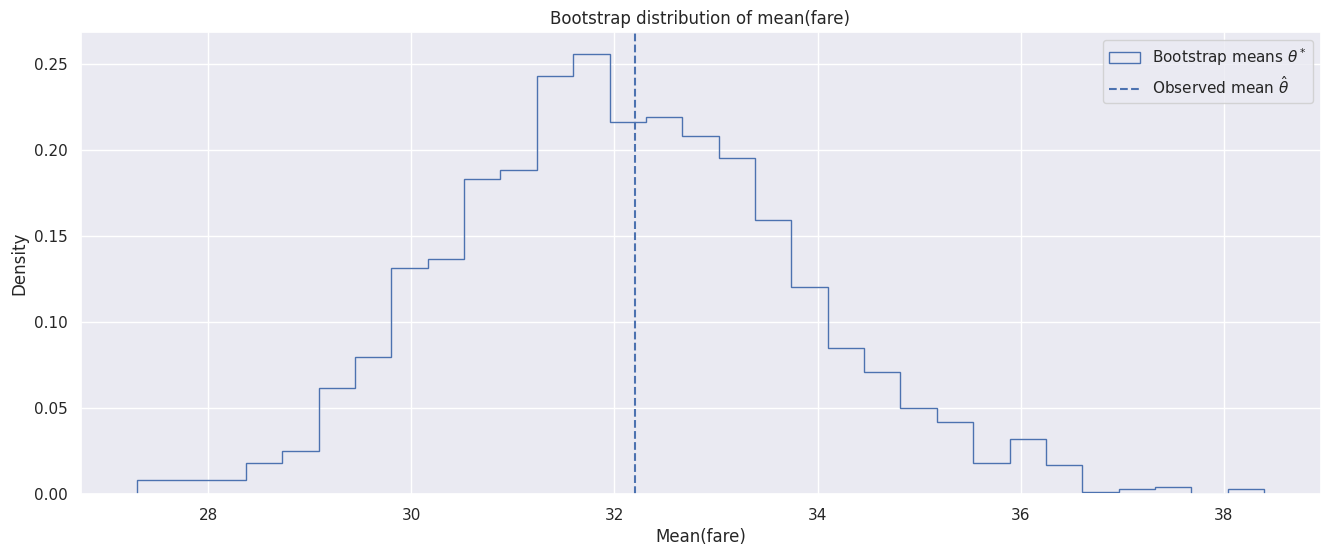

In [28]:
bins = np.histogram_bin_edges(theta_boot, bins='fd')
plt.figure()
plt.hist(theta_boot, bins=bins, density=True, histtype='step', label='Bootstrap means $\\theta^*$')
plt.axvline(theta_hat, linestyle='--', label='Observed mean $\\hat{\\theta}$')
plt.xlabel(f'Mean({column})')
plt.ylabel('Density')
plt.title(f'Bootstrap distribution of mean({column})')
plt.legend()
plt.show()

In [29]:
def ci_percentile(theta_boot, alpha=0.05):
    """Percentile CI: [q_{α/2}, q_{1-α/2}] of the bootstrap distribution."""
    lo = np.quantile(theta_boot, alpha/2)
    hi = np.quantile(theta_boot, 1 - alpha/2)
    return lo, hi

# Confidence intervals
alpha = 0.05
ci_pct  = ci_percentile(theta_boot, alpha=alpha)

print(f"{int((1-alpha)*100)}% CI (percentile): [{ci_pct[0]:.3f}, {ci_pct[1]:.3f}]")

95% CI (percentile): [29.120, 35.644]


This method is the simplest one and it is most likely [the worst one](https://stats.stackexchange.com/questions/355781/is-it-true-that-the-percentile-bootstrap-should-never-be-used). It's known to produce poor results when the distribution of sampled statistic is skewed.

A less biased method is the **basic (reverse-percentile) bootstrap CI**. In that, you use the deviation of sample means from the mean of sample means to estimate the confidence interval.

In [30]:
def ci_basic(theta_hat, theta_boot, alpha=0.05):
    """
    Basic (reverse-percentile) CI:
    [ 2θ̂ - q_{1-α/2}(θ*),  2θ̂ - q_{α/2}(θ*) ].
    """
    q_lo = np.quantile(theta_boot, alpha/2)
    q_hi = np.quantile(theta_boot, 1 - alpha/2)
    lo = 2*theta_hat - q_hi
    hi = 2*theta_hat - q_lo
    return lo, hi

# Confidence intervals
alpha = 0.05
ci_basic_ = ci_basic(theta_hat, theta_boot, alpha=alpha)

print(f"{int((1-alpha)*100)}% CI (basic):      [{ci_basic_[0]:.3f}, {ci_basic_[1]:.3f}]")

95% CI (basic):      [28.764, 35.289]


## Bootstrap for classifier performance

We estimate generalization performance using **bootstrap with out-of-bag (OOB) evaluation**.
For each bootstrap draw of size $n$ from the *training* set:
1. Fit the pipeline on the in-bag sample.
2. Evaluate on OOB points (not drawn). This yields an OOB score per iteration.

This provides a CI for the **OOB estimator**.


In [31]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, shuffle=True, random_state=SEED
)

n = len(X_train)
B = 500  # iterations
rng = np.random.default_rng(SEED)

acc_oob = []

for _ in tqdm(range(B)):
    # Bootstrap sample indices (size n, with replacement)
    idx_boot = rng.integers(0, n, size=n)
    in_bag = np.array(idx_boot)
    in_bag_set = set(in_bag.tolist())
    oob_idx = np.array([i for i in range(n) if i not in in_bag_set])

    if len(oob_idx) == 0:
        continue

    # Fit on in-bag
    pipe.fit(X_train.iloc[in_bag], y_train[in_bag])
    prob_oob = pipe.predict_proba(X_train.iloc[oob_idx])[:, 1]
    y_oob = y_train[oob_idx]

    # Accuracy (defined even if OOB is single-class)
    pred_oob = (prob_oob >= 0.5).astype(int)
    acc_out = accuracy_score(y_oob, pred_oob)
    acc_oob.append(acc_out)

acc_oob = np.array(acc_oob, dtype=float)

print(f"Collected {len(acc_oob)} OOB accuracy iterations.")

  0%|          | 0/500 [00:00<?, ?it/s]

Collected 500 OOB accuracy iterations.


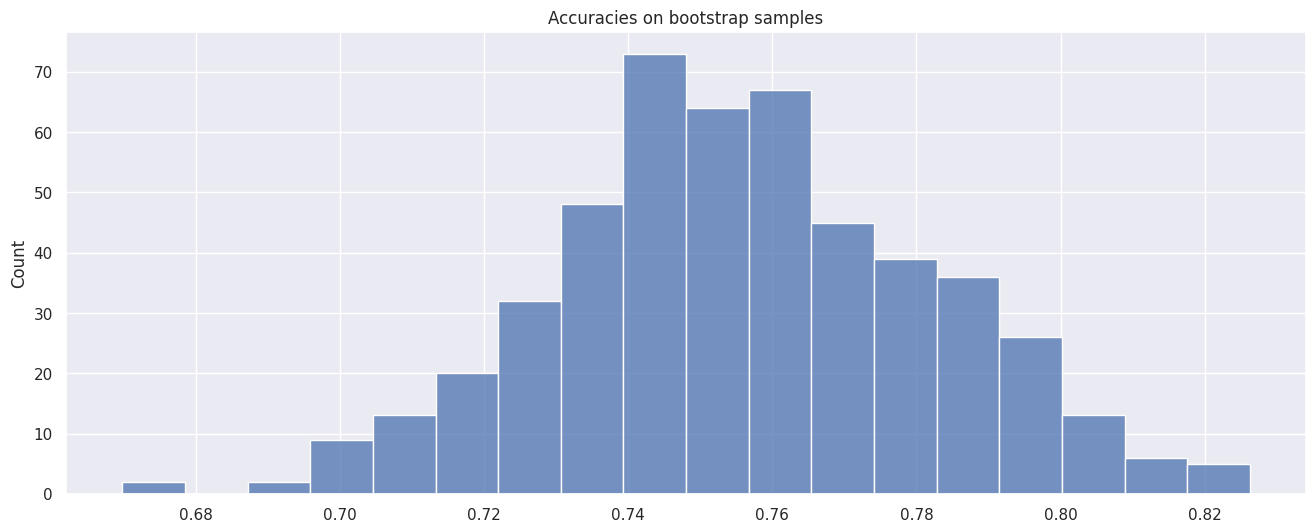

In [32]:
sns.histplot(acc_oob)
plt.title('Accuracies on bootstrap samples')
plt.show()

In [33]:
# Percentile CIs for these bootstrap estimators
alpha = 0.05

def pct_ci(x):
    return np.quantile(x, alpha / 2), np.quantile(x, 1 - alpha / 2)

print("— Accuracy —")
lo, hi = pct_ci(acc_oob)
print(f"OOB ACC (median): {np.median(acc_oob):.3f}  CI: [{lo:.3f}, {hi:.3f}]")

# External check on held-out test set
pipe.fit(X_train, y_train)
test_acc = accuracy_score(y_test, pipe.predict(X_test))
print(f"Held-out test ACC: {test_acc:.3f}")

— Accuracy —
OOB ACC (median): 0.755  CI: [0.705, 0.807]
Held-out test ACC: 0.813
